In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("deepcontractor/smoke-detection-dataset")

print("Path to dataset files:", path)

C:\Users\ahmed\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\ahmed\.cache\kagglehub\datasets\deepcontractor\smoke-detection-dataset\versions\1


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, accuracy_score, roc_curve, roc_auc_score, auc


In [3]:
df = pd.read_csv(
    r"C:\Users\ahmed\.cache\kagglehub\datasets\deepcontractor\smoke-detection-dataset\versions\1\smoke_detection_iot.csv")
print(df.head())


   Unnamed: 0         UTC  Temperature[C]  Humidity[%]  TVOC[ppb]  eCO2[ppm]  \
0           0  1654733331          20.000        57.36          0        400   
1           1  1654733332          20.015        56.67          0        400   
2           2  1654733333          20.029        55.96          0        400   
3           3  1654733334          20.044        55.28          0        400   
4           4  1654733335          20.059        54.69          0        400   

   Raw H2  Raw Ethanol  Pressure[hPa]  PM1.0  PM2.5  NC0.5  NC1.0  NC2.5  CNT  \
0   12306        18520        939.735    0.0    0.0    0.0    0.0    0.0    0   
1   12345        18651        939.744    0.0    0.0    0.0    0.0    0.0    1   
2   12374        18764        939.738    0.0    0.0    0.0    0.0    0.0    2   
3   12390        18849        939.736    0.0    0.0    0.0    0.0    0.0    3   
4   12403        18921        939.744    0.0    0.0    0.0    0.0    0.0    4   

   Fire Alarm  
0           0  


In [4]:
df. info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62630 entries, 0 to 62629
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      62630 non-null  int64  
 1   UTC             62630 non-null  int64  
 2   Temperature[C]  62630 non-null  float64
 3   Humidity[%]     62630 non-null  float64
 4   TVOC[ppb]       62630 non-null  int64  
 5   eCO2[ppm]       62630 non-null  int64  
 6   Raw H2          62630 non-null  int64  
 7   Raw Ethanol     62630 non-null  int64  
 8   Pressure[hPa]   62630 non-null  float64
 9   PM1.0           62630 non-null  float64
 10  PM2.5           62630 non-null  float64
 11  NC0.5           62630 non-null  float64
 12  NC1.0           62630 non-null  float64
 13  NC2.5           62630 non-null  float64
 14  CNT             62630 non-null  int64  
 15  Fire Alarm      62630 non-null  int64  
dtypes: float64(8), int64(8)
memory usage: 7.6 MB


In [5]:
df.isna().sum()

Unnamed: 0        0
UTC               0
Temperature[C]    0
Humidity[%]       0
TVOC[ppb]         0
eCO2[ppm]         0
Raw H2            0
Raw Ethanol       0
Pressure[hPa]     0
PM1.0             0
PM2.5             0
NC0.5             0
NC1.0             0
NC2.5             0
CNT               0
Fire Alarm        0
dtype: int64

In [6]:
df.describe()


,Unnamed: 0,UTC,Temperature[C],Humidity[%],TVOC[ppb],eCO2[ppm],Raw H2,Raw Ethanol,Pressure[hPa],PM1.0,PM2.5,NC0.5,NC1.0,NC2.5,CNT,Fire Alarm
count,62630.000000,6.263000e+04,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000,62630.000000
mean,31314.500000,1.654792e+09,15.970424,48.539499,1942.057528,670.021044,12942.453936,19754.257912,938.627649,100.594309,184.467770,491.463608,203.586487,80.049042,10511.386157,0.714626
std,18079.868017,1.100025e+05,14.359576,8.865367,7811.589055,1905.885439,272.464305,609.513156,1.331344,922.524245,1976.305615,4265.661251,2214.738556,1083.383189,7597.870997,0.451596
min,0.000000,1.654712e+09,-22.010000,10.740000,0.000000,400.000000,10668.000000,15317.000000,930.852000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15657.250000,1.654743e+09,10.994250,47.530000,130.000000,400.000000,12830.000000,19435.000000,938.700000,1.280000,1.340000,8.820000,1.384000,0.033000,3625.250000,0.000000
50%,31314.500000,1.654762e+09,20.130000,50.150000,981.000000,400.000000,12924.000000,19501.000000,938.816000,1.810000,1.880000,12.450000,1.943000,0.044000,9336.000000,1.000000
75%,46971.750000,1.654778e+09,25.409500,53.240000,1189.000000,438.000000,13109.000000,20078.000000,939.418000,2.090000,2.180000,14.420000,2.249000,0.051000,17164.750000,1.000000
max,62629.000000,1.655130e+09,59.930000,75.200000,60000.000000,60000.000000,13803.000000,21410.000000,939.861000,14333.690000,45432.260000,61482.030000,51914.680000,30026.438000,24993.000000,1.000000


In [7]:
X = df.drop(columns=['Fire Alarm', 'Unnamed: 0'])
y = df['Fire Alarm']

In [8]:
X_stand = StandardScaler()
X_scaled = X_stand.fit_transform(X)

In [9]:
print(X_scaled[:5])


[[-0.53394841  0.28062169  0.99494707 -0.24861434 -0.14167861 -2.3359354
  -2.02500594  0.83176078 -0.10904333 -0.09334044 -0.11521485 -0.09192422
  -0.07388861 -1.38347572]
 [-0.53393932  0.2816663   0.91711549 -0.24861434 -0.14167861 -2.19279625
  -1.8100786   0.83852093 -0.10904333 -0.09334044 -0.11521485 -0.09192422
  -0.07388861 -1.38334411]
 [-0.53393022  0.28264127  0.83702792 -0.24861434 -0.14167861 -2.08635944
  -1.62468325  0.83401417 -0.10904333 -0.09334044 -0.11521485 -0.09192422
  -0.07388861 -1.38321249]
 [-0.53392113  0.28368588  0.76032434 -0.24861434 -0.14167861 -2.02763568
  -1.48522658  0.83251191 -0.10904333 -0.09334044 -0.11521485 -0.09192422
  -0.07388861 -1.38308087]
 [-0.53391204  0.28473048  0.6937727  -0.24861434 -0.14167861 -1.97992263
  -1.36709857  0.83852093 -0.10904333 -0.09334044 -0.11521485 -0.09192422
  -0.07388861 -1.38294926]]


In [10]:
model = RandomForestClassifier()
model.fit(X_scaled, y)
importances = model.feature_importances_

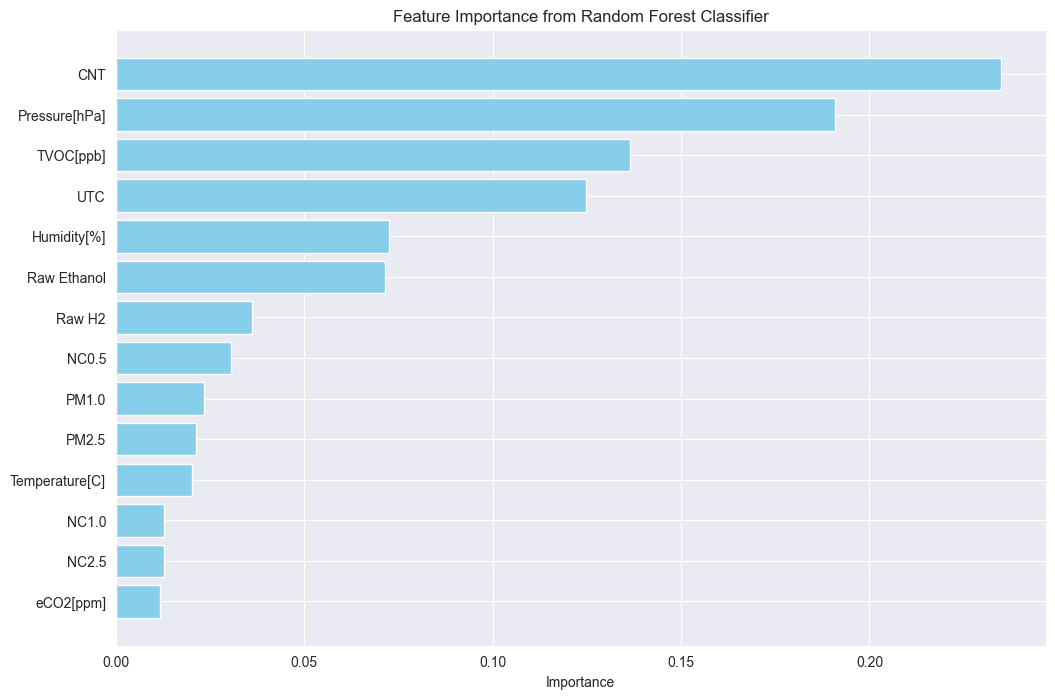

In [11]:
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest Classifier')
plt.gca().invert_yaxis()
plt.show()

In [12]:
selector = RFE(model)
selector.fit(X_scaled, y)
selected_features = X.columns[selector.support_]
importances = model.feature_importances_

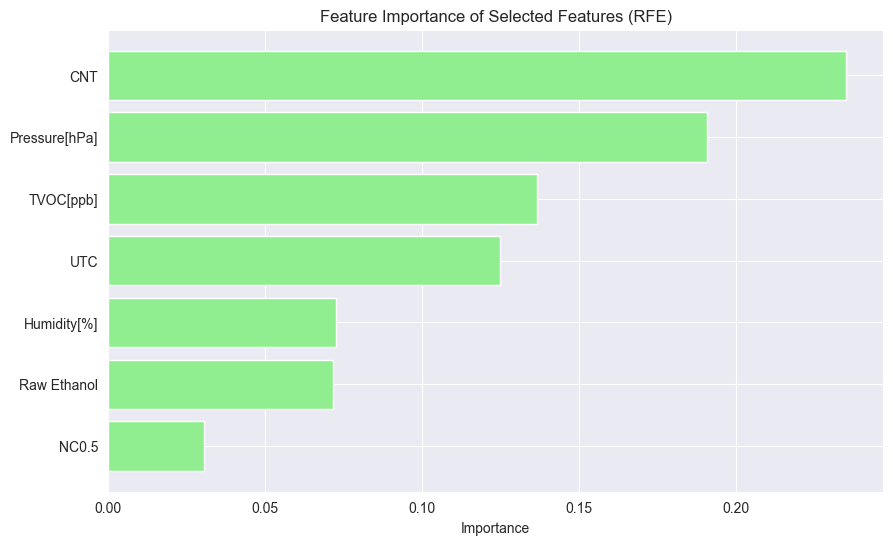

In [13]:
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
importance_df = importance_df[importance_df['Feature'].isin(selected_features)].sort_values(by='Importance',
                                                                                            ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='lightgreen')
plt.xlabel('Importance')
plt.title('Feature Importance of Selected Features (RFE)')
plt.gca().invert_yaxis()
plt.show()

In [14]:
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

rfe_scaled = X_scaled_df[importance_df['Feature']].copy()
rfe_scaled['Fire Alarm'] = y.values

rfe_scaled.to_csv('data/features_selected_rfe.csv', index=False)

In [15]:
rfe = pd.read_csv('data/features_selected_rfe.csv')

In [16]:
Xr = rfe.drop(columns=['Fire Alarm'])
yr = rfe['Fire Alarm']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

In [18]:
models = {
    'logistic regression': LogisticRegression(),
    'Decision tree': DecisionTreeClassifier(),
    'Random forest': RandomForestClassifier(),
    'Support Vector Machine': SVC()
}


In [19]:
performance = pd.DataFrame({
    'Model':['Logistic Regression','Decision Tree','Random Forest','Support Vector Machine']
})
a = []
results_a = []


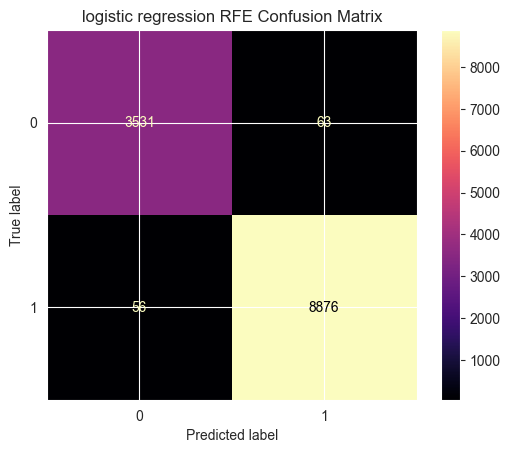

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      3594
           1       0.99      0.99      0.99      8932

    accuracy                           0.99     12526
   macro avg       0.99      0.99      0.99     12526
weighted avg       0.99      0.99      0.99     12526

logistic regression: train acc: 99.07%, accuracy: 99.05%


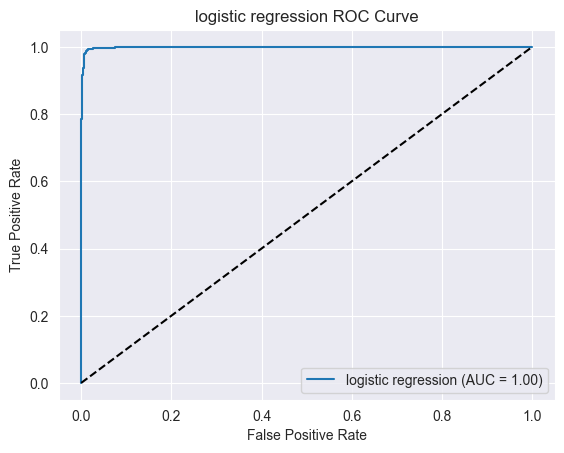

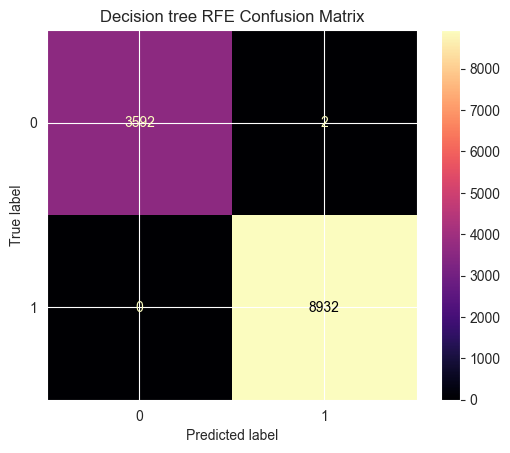

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3594
           1       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526

Decision tree: train acc: 100.00%, accuracy: 99.98%


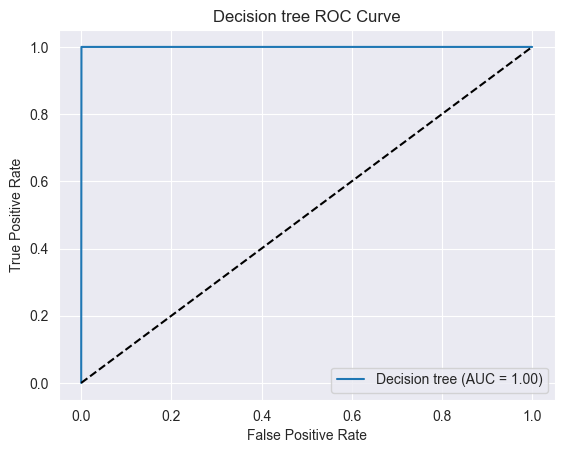

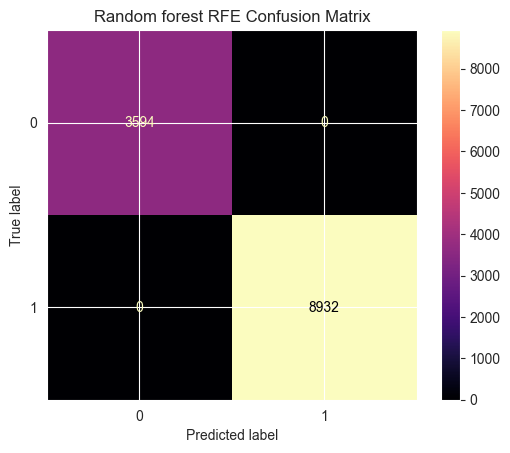

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3594
           1       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526

Random forest: train acc: 100.00%, accuracy: 100.00%


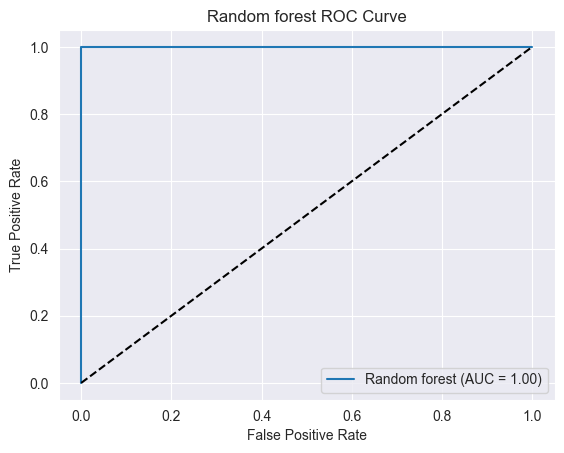

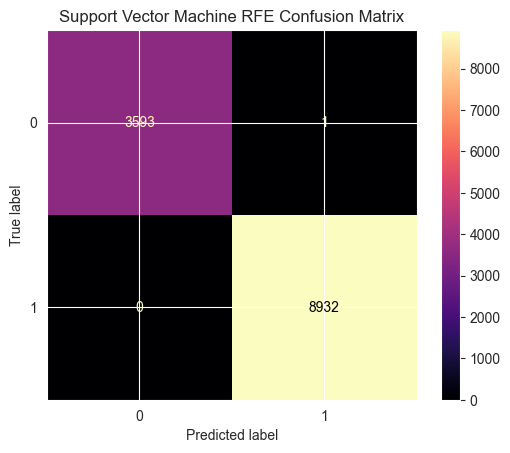

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      3594
           1       1.00      1.00      1.00      8932

    accuracy                           1.00     12526
   macro avg       1.00      1.00      1.00     12526
weighted avg       1.00      1.00      1.00     12526

Support Vector Machine: train acc: 99.96%, accuracy: 99.99%


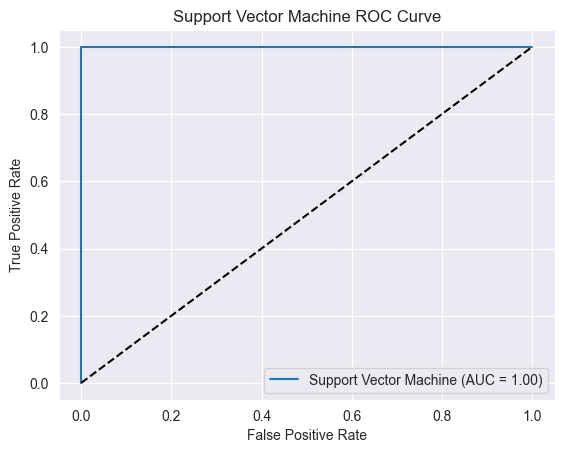


Performance Summary:
                     Model Train Accuracy Test Accuracy   AUC
0     logistic regression         99.07%        99.05%  1.00
1           Decision tree        100.00%        99.98%  1.00
2           Random forest        100.00%       100.00%  1.00
3  Support Vector Machine         99.96%        99.99%  1.00


In [21]:
for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    cm = confusion_matrix(y_test, pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(cmap=plt.cm.magma)
    plt.title(model_name + ' RFE Confusion Matrix')
    plt.show()

    print('Classification Report:\n', classification_report(y_test, pred))

    train_acc = accuracy_score(y_train, model.predict(X_train)) * 100
    test_acc = accuracy_score(y_test, pred) * 100
    print(f'{model_name}: train acc: {train_acc:.2f}%, accuracy: {test_acc:.2f}%')

    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    if len(model.classes_) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=model.classes_[1])
        roc_auc = auc(fpr, tpr)

        plt.figure()
        plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(model_name + ' ROC Curve')
        plt.legend(loc="lower right")
        plt.show()
    else:
        roc_auc = None
        print(f"{model_name}: ROC/AUC only supported for binary classification.")

    # Save metrics 
    a.append(f"{test_acc:.2f}%")
    results_a.append({
        "Model": model_name,
        "Train Accuracy": f"{train_acc:.2f}%",
        "Test Accuracy": f"{test_acc:.2f}%",
        "AUC": f"{roc_auc:.2f}" if roc_auc is not None else "N/A"
    })

performance['RFE feat. Acc.'] = a
performance_df = pd.DataFrame(results_a)
print("\nPerformance Summary:\n", performance_df)


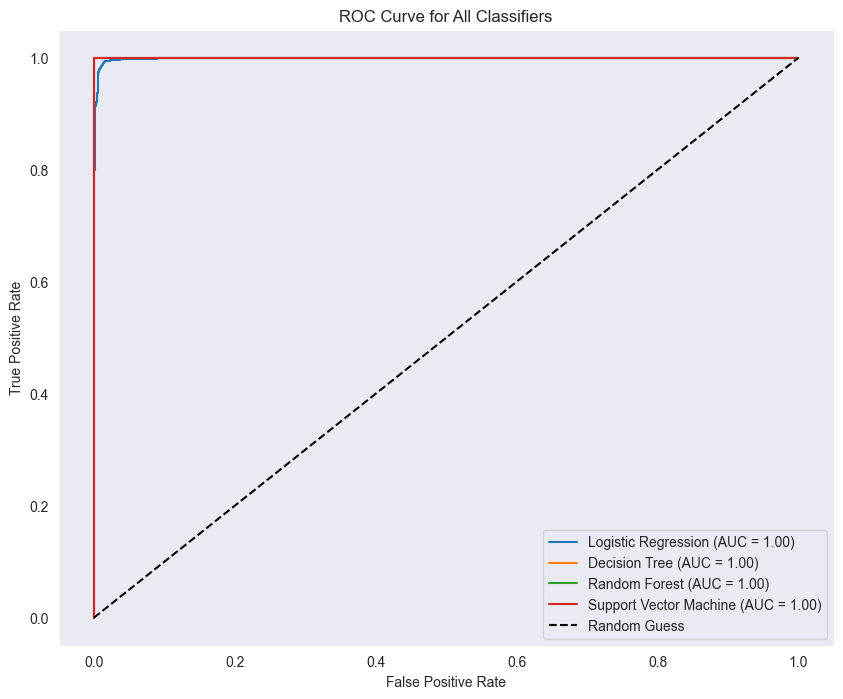

In [23]:
plt.figure(figsize=(10, 8))
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC()
}

for name, model in models.items():
    # Fit the model
    model.fit(X_train, y_train)

    # Get predicted probabilities or decision function
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc_score = roc_auc_score(y_test, y_score)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for All Classifiers')
plt.legend(loc='lower right')
plt.grid()
plt.show()
